# Import libraries

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Generating data

In [34]:
img_size = 128   #resize img to 128x128 pixels
batch_size = 32     #32 images processed at a time during training

train_datagen = ImageDataGenerator(
    rescale=1/255.0,   #normalize pixel values
    rotation_range=15, 
    zoom_range=0.1,    
    width_shift_range=0.1, 
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3]     #create variation of training imgs
)

valid_datagen = ImageDataGenerator(rescale=1/255.0)    #rescale only 
test_datagen = ImageDataGenerator(rescale=1/255.0) 


# Load data

In [ ]:
train_data = train_datagen.flow_from_directory(   #flow_from_directory: each subfolder represents a class
    "dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    "dataset/valid",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  #keep the order of images consistent
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  
)

Found 2637 images belonging to 9 classes.
Found 760 images belonging to 9 classes.
Found 290 images belonging to 9 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), padding="same", activation='relu', input_shape=(img_size, img_size, 3)), 
    BatchNormalization(),                                                            
    Conv2D(32, (3,3), padding="same", activation='relu'), # double conv2D layers learn more complex features than single conv
    BatchNormalization(), #stabilize training, allow higher learning rates
    MaxPooling2D(2,2),    #reduces image size by half
    Dropout(0.25), #prevent overfitting by randomly disabling 25% of neurons

    Conv2D(64, (3,3), padding="same", activation='relu'), 
    BatchNormalization(), 
    Conv2D(64, (3,3), padding="same", activation='relu'), 
    BatchNormalization(), 
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding="same", activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding="same", activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), padding="same", activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding="same", activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),  #converts 3d to 1d bc dense layer expects 1d input

    Dense(256, activation='relu'),  #256 neurons, neurons combine learned features
    Dropout(0.3),   #drops 30% of neurons to prevent memorizing

    Dense(train_data.num_classes, activation='softmax') #converts outputs to probabilities
])
#optimizer decides how the model learns to reduce error
optimizer = Adam(learning_rate=0.0003) #lower learning rate to inc accuracy
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])  #track accuracy during training
model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', # watch validation accuracy
                   patience=5, # stop after 5 epochs with no improvement
                   restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', # reduce learning rate when val loss stops improving
                       factor=0.3, # reduce LR by 70%
                       patience=4)
]

c:\Users\Omama\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,372,969 (20.50 MB)

 Trainable params: 5,371,049 (20.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

# Train the model

In [38]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=60,  #model goes through data 60 times
    callbacks=callbacks 
)

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.1449 - loss: 2.9423 - val_accuracy: 0.1053 - val_loss: 2.1769 - learning_rate: 3.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.1741 - loss: 2.0738 - val_accuracy: 0.1711 - val_loss: 2.2565 - learning_rate: 3.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.2158 - loss: 1.9965 - val_accuracy: 0.2092 - val_loss: 2.2595 - learning_rate: 3.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.2522 - loss: 1.9182 - val_accuracy: 0.2250 - val_loss: 2.1464 - learning_rate: 3.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.2814 - loss: 1.8429 - val_accuracy: 0.2039 - val_loss: 2.0876 - learning_rate: 3.0000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.3292 - loss: 1.7858 - val_accuracy: 0.2947 - val_loss: 1.8760 - learning_rate: 3.0000e-04
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.3500 -

# Plot training curves

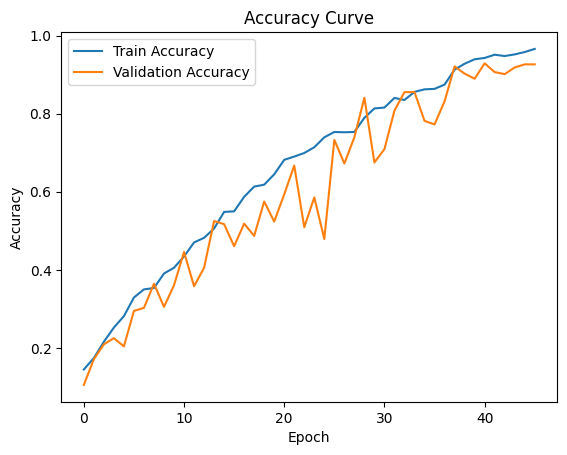

In [39]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

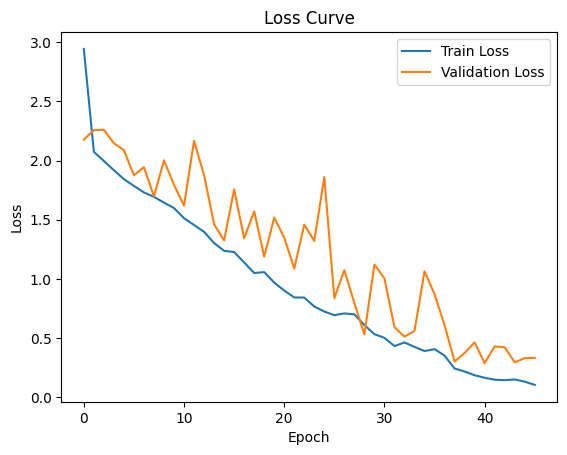

In [40]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluating the model

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 363ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 325ms/step - accuracy: 0.9289 - loss: 0.2889
Validation Accuracy: 0.9289
Validation Loss: 0.2889


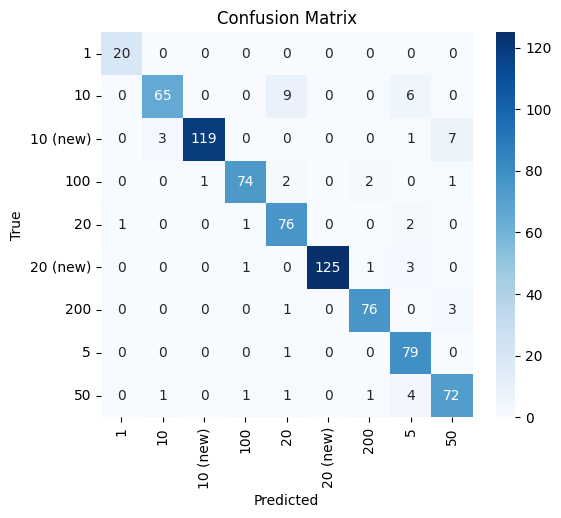

In [41]:
y_true = valid_data.classes
y_pred = np.argmax(model.predict(valid_data), axis=1)

val_loss, val_accuracy = model.evaluate(valid_data)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(valid_data.class_indices.keys()),
            yticklabels=list(valid_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [42]:
print(classification_report(
    y_true,
    y_pred, 
    target_names=list(valid_data.class_indices.keys())
))

              precision    recall  f1-score   support

           1       0.95      1.00      0.98        20
          10       0.94      0.81      0.87        80
    10 (new)       0.99      0.92      0.95       130
         100       0.96      0.93      0.94        80
          20       0.84      0.95      0.89        80
    20 (new)       1.00      0.96      0.98       130
         200       0.95      0.95      0.95        80
           5       0.83      0.99      0.90        80
          50       0.87      0.90      0.88        80

    accuracy                           0.93       760
   macro avg       0.93      0.93      0.93       760
weighted avg       0.93      0.93      0.93       760



10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 711ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.9310 - loss: 0.2933
Test Accuracy: 0.9310
Test Loss: 0.2933


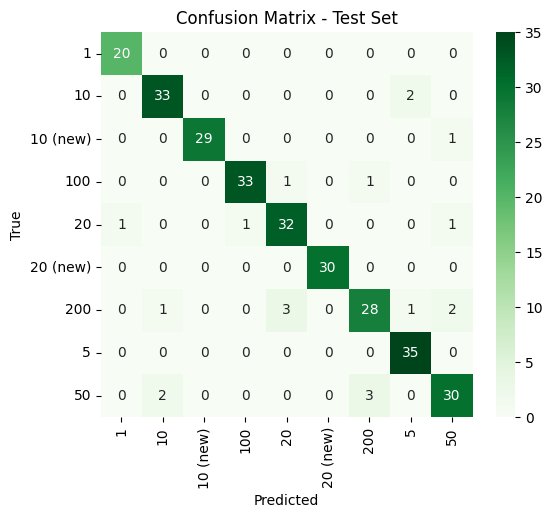

In [43]:
y_true_test = test_data.classes
y_pred_test = np.argmax(model.predict(test_data), axis=1)

test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", 
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [44]:
print(classification_report(
    y_true_test, 
    y_pred_test, 
    target_names=list(test_data.class_indices.keys())
))

              precision    recall  f1-score   support

           1       0.95      1.00      0.98        20
          10       0.92      0.94      0.93        35
    10 (new)       1.00      0.97      0.98        30
         100       0.97      0.94      0.96        35
          20       0.89      0.91      0.90        35
    20 (new)       1.00      1.00      1.00        30
         200       0.88      0.80      0.84        35
           5       0.92      1.00      0.96        35
          50       0.88      0.86      0.87        35

    accuracy                           0.93       290
   macro avg       0.93      0.94      0.93       290
weighted avg       0.93      0.93      0.93       290



# Prediction on unseen image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Currency: 10


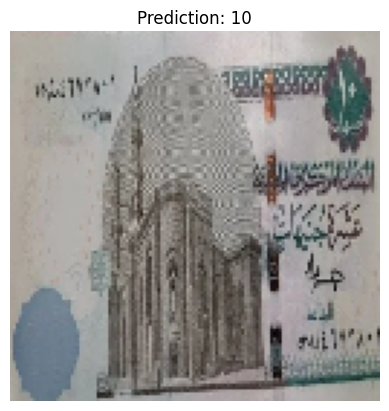

In [ ]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(img_size, img_size)) #load img and resize
    img_array = image.img_to_array(img) / 255.0  #converts img to array and normalizes
    img_array = np.expand_dims(img_array, axis=0) #expand dimension to add batch, model expect(batch,height,width,channel)
    
    prediction = model.predict(img_array)  #returns array of percentages for each class
    class_name = list(valid_data.class_indices.keys())[np.argmax(prediction)] #maps class name to its percentage to find max
    
    print("Predicted Currency:", class_name)
    plt.imshow(img)
    plt.title(f"Prediction: {class_name}")
    plt.axis('off')

# predict_image("path/to/your/image.jpg")

In [85]:
model.save('egyptian_currency_model.keras')